In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import warnings
import os
import cv2
from PIL import Image,ImageOps
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import random as rnd
import keras_tuner

import itertools
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop,Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

C:\Users\Blu-Ray\Downloads\semester 4\machine\AnimalImages\cats
C:\Users\Blu-Ray\Downloads\semester 4\machine\AnimalImages\dogs


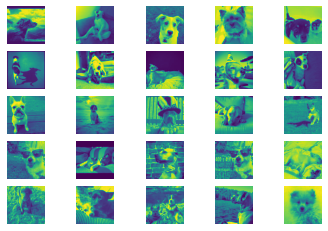

In [2]:
# define a list of dictionaries where each dictionary contains the path to a folder and an empty array
folder_paths = [{"path":r"C:\Users\Blu-Ray\Downloads\semester 4\machine\AnimalImages\cats", "arr":[]},
                {"path":r"C:\Users\Blu-Ray\Downloads\semester 4\machine\AnimalImages\dogs", "arr":[]}]
# Define the number of samples to use from each class
sample_size=10000

#The image load process
for folder in folder_paths:
    print(folder["path"])
    for cnt,filename in enumerate(os.listdir(folder["path"])):
        
        if cnt < sample_size:
            if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.jpeg'):
                img = ImageOps.grayscale(Image.open(os.path.join(folder["path"], filename)))
                img = img.resize((150,150))

                #Display some images for first look
                if cnt < 25:  
                    plt.subplot(5,5,cnt+1)
                    plt.imshow(img)
                    plt.axis("off")

                folder["arr"].append(np.array(img))
    folder["arr"] = np.array(folder["arr"])

Train_O: (9999, 150, 150)
Train_R: (10000, 150, 150)

X_train: (13999, 150, 150)
y_train: (13999,)



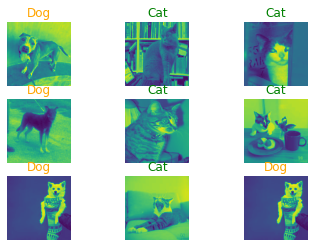

In [3]:
titles={0:"Cat",1:"Dog"}

Train_O = folder_paths[0]["arr"][0:sample_size]
Train_R = folder_paths[1]["arr"][0:sample_size]

print("""Train_O: {}
Train_R: {}
""".format(Train_O.shape,Train_R.shape))

# Concatenate numpy arrays
X = np.concatenate((Train_O,Train_R),axis=0)
# Create a numpy array of labels (0 for Cat, 1 for Dog)
y = np.concatenate((np.zeros(Train_O.shape[0]),np.ones(Train_R.shape[0])),axis=0)

from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("""X_train: {}
y_train: {}
""".format(X_train.shape,Y_train.shape))
###############################################################################
# Display a random selection of 9 images from the training set, with their corresponding labels
indexes=[]
for i in range(9):
    index=rnd.randint(1,300)
    indexes.append(index)
    if indexes.count(index)!=0:
        pass
    else:
        index=rnd.randint(0,300)    
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[index])
    plt.axis("off")
    plt.title(titles[Y_train[index]],color="green" if Y_train[index] == 0 else "orange")

In [4]:
#normalizing the pixel values
X_train= X_train/256.0
X_val= X_val/256.0


In [5]:

#reshaping data
X_train = X_train.reshape(-1,X_train.shape[1],X_train.shape[2],1)
X_val = X_val.reshape(-1,X_train.shape[1],X_train.shape[2],1)
Y_train = Y_train.reshape(Y_train.shape[0],1)
Y_val = Y_test.reshape(Y_test.shape[0],1)

print("X_train shape:",X_train.shape)
print("X_val shape:",X_val.shape)
print("Y_train shape:",Y_train.shape)
print("Y_val shape:",Y_val.shape)

X_train shape: (13999, 150, 150, 1)
X_val shape: (6000, 150, 150, 1)
Y_train shape: (13999, 1)
Y_val shape: (6000, 1)


In [6]:
#defining model
model = Sequential()

#adding convolution layer
model.add(Conv2D(filters = 12, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu', input_shape = X_train.shape[1:]))

#adding pooling layer
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 24, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))

model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

#adding fully connected layer
model.add(Flatten())
model.add(Dense(512, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(Y_train.shape[1], activation = "sigmoid"))

#compiling the model
optimizer = Adam(lr=0.001)
model.compile(optimizer = optimizer , loss = "binary_crossentropy", metrics=["accuracy"])

In [7]:
#Training the model
epochs = 10
batch_size = 250
model.fit(X_train,Y_train,batch_size,epochs)

Epoch 1/10
56/56 [==============================] - 123s 2s/step - loss: 0.8420 - accuracy: 0.5677
Epoch 2/10
56/56 [==============================] - 126s 2s/step - loss: 0.5923 - accuracy: 0.6889
Epoch 3/10
56/56 [==============================] - 128s 2s/step - loss: 0.5174 - accuracy: 0.7471
Epoch 4/10
56/56 [==============================] - 143s 3s/step - loss: 0.4514 - accuracy: 0.7900
Epoch 5/10
56/56 [==============================] - 130s 2s/step - loss: 0.3970 - accuracy: 0.8203
Epoch 6/10
56/56 [==============================] - 124s 2s/step - loss: 0.3459 - accuracy: 0.8522
Epoch 7/10
56/56 [==============================] - 123s 2s/step - loss: 0.2867 - accuracy: 0.8820
Epoch 8/10
56/56 [==============================] - 123s 2s/step - loss: 0.2365 - accuracy: 0.9090
Epoch 9/10
56/56 [==============================] - 127s 2s/step - loss: 0.1853 - accuracy: 0.9341
Epoch 10/10
56/56 [==============================] - 124s 2s/step - loss: 0.1349 - accuracy: 0.9574


In [8]:
 #------------------------Data-Augmentation---------------------#
data_aug_config = {
        "rotation_range": 0.3,
        "zoom_range": 0.3,
        "width_shift_range": 0.0,
        "height_shift_range":0.0}

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # dimesion reduction
        rotation_range= data_aug_config["rotation_range"],  # randomly rotate images in the range 5 degrees
        zoom_range= data_aug_config["zoom_range"], # Randomly zoom image 5%
        width_shift_range= data_aug_config["width_shift_range"],  # randomly shift images horizontally 5%
        height_shift_range= data_aug_config["height_shift_range"],  # randomly shift images vertically 5%
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images
datagen

In [9]:

datagen.fit(X_train)

In [15]:
def CNN_model_tuner(hp):
    kernel_size = (3,3)
    pool_size = (2,2)
    dropout_coeff_conv = hp.Float("conv_dropout", min_value=0.05, max_value=0.2)#, sampling="log")
    dropout_coeff_hidden = hp.Float("hidden_dropout", min_value=0.05, max_value=0.2)#, sampling="log")
    
    filter_num = hp.Int('filter_num', min_value=2, max_value=24, step=2)
    conv_layer_num =hp.Int('conv_layer', min_value=1, max_value=5, step=1)
    hidden_layer_num = hp.Int('hidden_layer_num', min_value=1, max_value=5, step=1)
    layer_unit = hp.Int('layer_unit',156,1048,100)
    
    output_num = Y_train.shape[1]
    input_shape = X_train.shape[1:]
    learning_rate = 0.001#hp.Float("lr", min_value=0.0005, max_value=0.002, sampling="log")

    model = Sequential()
      #--------------------Conv-Pool-Dropout----------------------------#
    for i in range(conv_layer_num):
        model.add(Conv2D(
            filters=filter_num, kernel_size=kernel_size, padding="same"
            ,activation='relu', input_shape = input_shape))
        filter_num*=2
        model.add(MaxPool2D(pool_size = pool_size,padding="same")) 
        model.add(Dropout(dropout_coeff_conv))
    
    #--------------------Fully-connected-----------------------------#
    model.add(Flatten())
    
    print("layer unit(hidden):",layer_unit)
    for i in range(hidden_layer_num):
        model.add(Dense(layer_unit, activation= 'relu'))
        model.add(Dropout(dropout_coeff_hidden))
    model.add(Dense(1,activation='sigmoid'))
    
    #-----------------------Compile the Model----------------------#
    optimizer = Adam(lr=learning_rate)
    model.compile(optimizer=optimizer,loss = "binary_crossentropy",
                metrics=["accuracy"])
    return model


reduce_lr = ReduceLROnPlateau( #Reduce learning rate when a metric has stopped improving.
    monitor="val_loss",
    factor=0.1,
    patience=10,
    verbose=0,
    mode="auto",
    min_delta=0.0001,
    cooldown=0,
    min_lr=0
)


  

In [11]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

train_generator = datagen.flow(
    x=X_train,
    y=Y_train,
    batch_size=1,
    shuffle=False,
    subset='training')

validation_generator = datagen.flow(
    x=X_train,
    y=Y_train,
    batch_size=1,
    shuffle=False,
    subset='validation')
trial_number = 1
tuner = keras_tuner.RandomSearch(
    CNN_model_tuner,
    objective='val_accuracy',
    max_trials = trial_number, #Number of trials
    overwrite=True,
    project_name="cat_dog_CNN")

tuner.search(datagen.flow(X_train,Y_train, batch_size=64).x, datagen.flow(X_train,Y_train, batch_size=64).y, 
             epochs=10,batch_size = 250, validation_data=(X_val, Y_val),callbacks=[reduce_lr])
best_model = tuner.get_best_models()[0]


Trial 1 Complete [00h 38m 01s]
val_accuracy: 0.7260000109672546

Best val_accuracy So Far: 0.7260000109672546
Total elapsed time: 00h 38m 01s
INFO:tensorflow:Oracle triggered exit
layer unit(hidden): 756


188/188 [==============================] - 25s 108ms/step
Val_score = 0.726


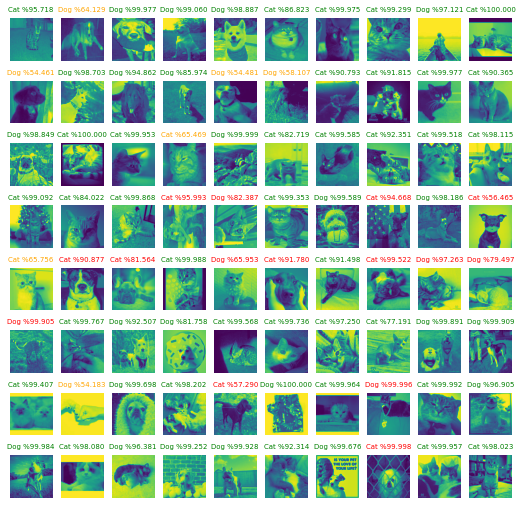

In [12]:
def scale_number(num, in_min, in_max, out_min, out_max):
    # First, calculate the input range
    in_range = in_max - in_min
    # Next, calculate the output range
    out_range = out_max - out_min
    # Calculate the scaled value
    scaled = (num - in_min) / in_range * out_range + out_min
    # Return the scaled value
    return scaled

Y_pred = best_model.predict(X_val)
results = np.array(np.array(Y_pred>0.5).T == Y_test)
score = results.sum()/len(results[0])
print("Val_score =",score)

display_grid = (8,10)
indexes = np.random.default_rng().choice(Y_pred.shape[0],
                         display_grid[0]*display_grid[1],replace=False)
plt.subplots(figsize=(9, 9))

for i in range(display_grid[0]*display_grid[1]):
    index = indexes[i]
    plt.subplot(display_grid[0],display_grid[1],i+1)
    plt.imshow(X_val[index])
    prob = Y_pred[index][0]*100
    
    prob = round(scale_number(prob,50,100,50,100),3) if prob > 50 else round(100 - scale_number(prob,0,50,0,50),3)    
        
    if [Y_pred[index] > 0.5][0][0] == Y_val[index][0]:
        color = "green"
        if prob<70:
            color="orange"
    else:
        color = "red"
    
    plt.title("{0} %{1:.3f}".format(
        titles[[Y_pred[index] > 0.5][0][0]],prob),color=color,
        fontsize=7)
    plt.axis("off")

In [24]:
def scale_number(num, in_min, in_max, out_min, out_max):
    # First, calculate the input range
    in_range = in_max - in_min# Next, calculate the output range
#     out_range CNN_model_tuner(hp):
#     kernel_size = (3,3)
#     pool_size = (2,2)
#     dropout_coeff_conv = hp.Float("conv_dropout", min_value=0.05, max_value=0.2)#, sampling="log")
#     dropout_coeff_hidden = hp.Float("hidden_dropout", min_value=0.05, max_value=0.2)#, sampling="log")
    
    filter_num = hp.Int('filter_num', min_value=2, max_value=24, step=2)
    conv_layer_num =hp.Int('conv_layer', min_value=1, max_value=5, step=1)
    hidden_layer_num = hp.Int('hidden_layer_num', min_value=1, max_value=5, step=1)
    layer_unit = hp.Int('layer_unit',156,1048,100)
    
    output_num = Y_train.shape[1]
    input_shape = X_train.shape[1:]
    learning_rate = 0.001#hp.Float("lr", min_value=0.0005, max_value=0.002, sampling="log")

    model = Sequential()
    #--------------------Conv-Pool-Dropout----------------------------#
    for i in range(conv_layer_num):
        model.add(Conv2D(
            filters=filter_num, kernel_size=kernel_size, padding="same"
            ,activation='relu', input_shape = input_shape))
        filter_num*=2
        model.add(MaxPool2D(pool_size = pool_size,padding="same")) 
        model.add(Dropout(dropout_coeff_conv))
    
    #--------------------Fully-connected-----------------------------#
    model.add(Flatten())
    
    print("layer unit(hidden):",layer_unit)
    for i in range(hidden_layer_num):
        model.add(Dense(layer_unit, activation= 'relu'))
        model.add(Dropout(dropout_coeff_hidden))
    model.add(Dense(1,activation='sigmoid'))
    
    #-----------------------Compile the Model----------------------#
    optimizer = Adam(lr=learning_rate)
    model.compile(optimizer=optimizer,loss = "binary_crossentropy",
                metrics=["accuracy"])
    return model


reduce_lr = ReduceLROnPlateau( #Reduce learning rate when a metric has stopped improving.
    monitor="val_loss",
    factor=0.1,
    patience=10,
    verbose=0,
    mode="auto",
    min_delta=0.0001,
    cooldown=0,
    min_lr=0
)


In [21]:
#evaluting the model
model.evaluate(X_val,Y_val)

188/188 [==============================] - 19s 77ms/step - loss: 0.7653 - accuracy: 0.7270


[0.7652973532676697, 0.7269999980926514]

layer unit(hidden): 756
188/188 [==============================] - 25s 105ms/step - loss: 0.9196 - accuracy: 0.7260


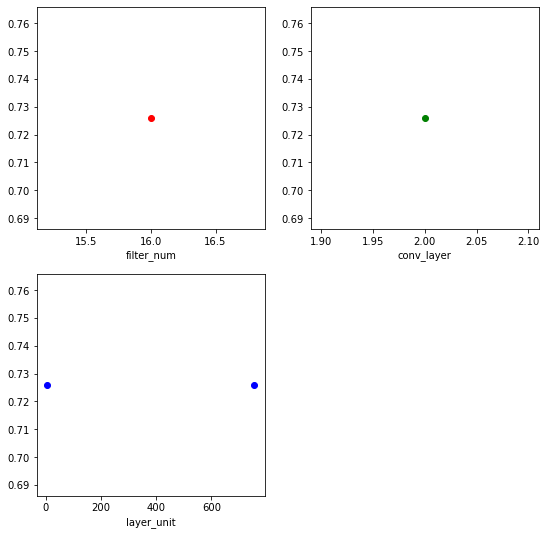

In [25]:
trial_hp,trial_accuracy = [],[]

for trial, hp in zip(tuner.get_best_models(trial_number), tuner.get_best_hyperparameters(trial_number)):
    trial_accuracy.append(trial.evaluate(X_val,Y_val)[1])
    trial_hp.append(hp.values)
    
df = pd.concat((pd.DataFrame(trial_hp),pd.DataFrame(trial_accuracy,columns=["accuracy"])),axis=1)
plt.subplots(figsize=(9,9))

def plotScatter(x,y,c,i):
    plt.subplot(2,2,i)
    plt.scatter(x=df[x],y = df[y], c=c)
    plt.xlabel(x)

plotScatter("filter_num","accuracy","red",1)
plotScatter("conv_layer","accuracy","green",2)
plotScatter("hidden_layer_num","accuracy","blue",3)
plotScatter("layer_unit","accuracy","blue",3)